# 05. VaR and CVaR Stress Testing

Compute Value at Risk and Conditional VaR for an equal-weight portfolio of the 8 sector ETFs,
using both historical and Monte Carlo methods, then compare normal-period risk against two
known stress windows: the March 2020 selloff and the 2022 rate hike period.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from risk_metrics import historical_var, historical_cvar, monte_carlo_var, monte_carlo_cvar, stress_test

## Portfolio daily returns

Equal-weight average of the 8 sector ETF daily returns.

In [2]:
prices = pd.read_csv('../data/raw/prices.csv', index_col=0, parse_dates=True)

sector_cols = [c for c in prices.columns if not c.startswith('^')]
sector_returns = prices[sector_cols].pct_change().dropna(how='all')
portfolio_returns = sector_returns.mean(axis=1).dropna()

print(f"Sector ETFs: {sector_cols}")
print(f"Portfolio return series: {len(portfolio_returns)} days, {portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")

Sector ETFs: ['XLF', 'XLK', 'XLE', 'XLU', 'XLY', 'XLP', 'XLV', 'XLI']
Portfolio return series: 2139 days, 2018-01-03 to 2026-07-10


## VaR / CVaR at 95% and 99%, historical vs Monte Carlo

In [3]:
rows = []
for confidence in [0.95, 0.99]:
    rows.append({
        'confidence': confidence,
        'method': 'historical',
        'VaR': historical_var(portfolio_returns, confidence),
        'CVaR': historical_cvar(portfolio_returns, confidence),
    })
    rows.append({
        'confidence': confidence,
        'method': 'monte_carlo',
        'VaR': monte_carlo_var(portfolio_returns, confidence),
        'CVaR': monte_carlo_cvar(portfolio_returns, confidence),
    })

risk_table = pd.DataFrame(rows)
risk_table

,confidence,method,VaR,CVaR
0,0.95,historical,0.015668,0.027175
1,0.95,monte_carlo,0.018412,0.023150
2,0.99,historical,0.030835,0.049645
3,0.99,monte_carlo,0.026339,0.030316


**Reading the table**: historical and Monte Carlo VaR/CVaR are close but not identical, since
Monte Carlo assumes normally distributed returns while the historical method uses the actual
empirical distribution, fat tails included. Any gap between the two is evidence of non-normality
in the return series (skew, excess kurtosis).

## Stress windows vs normal period

Compare historical VaR/CVaR in the full sample against two known stress windows: the March 2020
COVID selloff and the 2022 rate hike period.

In [4]:
full_sample = {
    'var_95': historical_var(portfolio_returns, 0.95),
    'cvar_95': historical_cvar(portfolio_returns, 0.95),
    'n_observations': len(portfolio_returns),
}

covid_crash = stress_test(portfolio_returns, '2020-02-15', '2020-04-15')
rate_hike_2022 = stress_test(portfolio_returns, '2022-01-01', '2022-12-31')

stress_comparison = pd.DataFrame([
    {'period': 'full_sample', **full_sample},
    {'period': 'covid_crash_2020', **covid_crash},
    {'period': 'rate_hike_2022', **rate_hike_2022},
])
stress_comparison

,period,var_95,cvar_95,n_observations
0,full_sample,0.015668,0.027175,2139
1,covid_crash_2020,0.086208,0.101071,41
2,rate_hike_2022,0.021868,0.029133,251


In [5]:
covid_multiple = stress_comparison.loc[1, 'var_95'] / stress_comparison.loc[0, 'var_95']
hike_multiple = stress_comparison.loc[2, 'var_95'] / stress_comparison.loc[0, 'var_95']

print(f"COVID crash VaR is {covid_multiple:.1f}x the full-sample VaR")
print(f"2022 rate hike VaR is {hike_multiple:.1f}x the full-sample VaR")

COVID crash VaR is 5.5x the full-sample VaR
2022 rate hike VaR is 1.4x the full-sample VaR


## Returns time series with stress windows marked

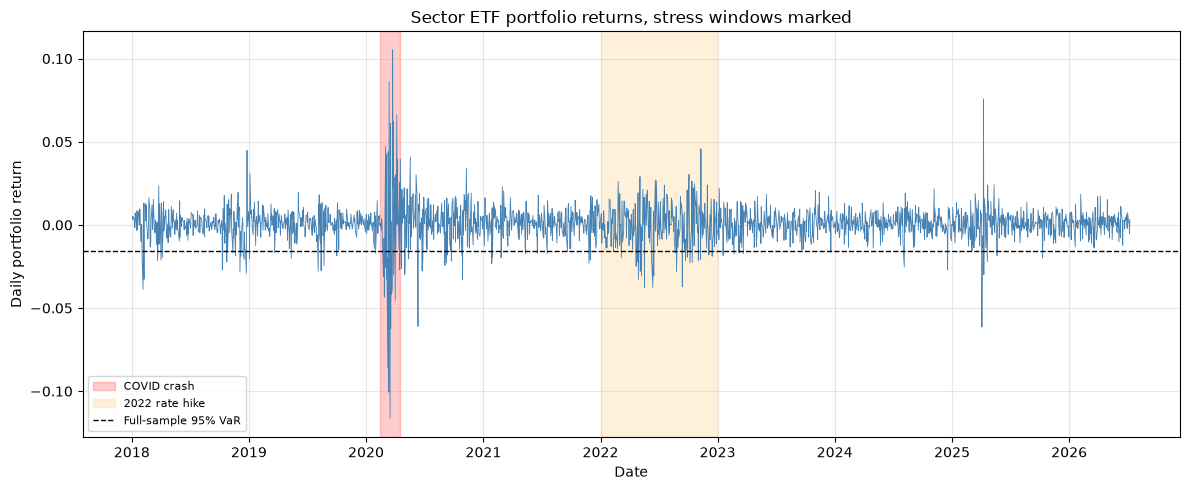

Saved figure: figures/05_returns_stress_windows.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(portfolio_returns.index, portfolio_returns.values, color='steelblue', linewidth=0.6)

ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15'), alpha=0.2, color='red', label='COVID crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), alpha=0.15, color='orange', label='2022 rate hike')

ax.axhline(-full_sample['var_95'], color='black', linestyle='--', linewidth=1, label='Full-sample 95% VaR')

ax.set_xlabel('Date')
ax.set_ylabel('Daily portfolio return')
ax.set_title('Sector ETF portfolio returns, stress windows marked')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../figures/05_returns_stress_windows.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/05_returns_stress_windows.png")